In [255]:
import pandas as pd
import numpy as np

In [256]:
df = pd.read_csv('spam.csv', encoding='latin1')


In [257]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [258]:
df.shape

(5572, 5)

In [259]:
#sequence 
#data cleaning->EDA->Text Preprocessing->Model building->Evalution->Improvement->website->deploy

Data Cleaning

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [261]:
# last 3 column are not important as mant null so we will drop it

In [262]:
df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [263]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [264]:
#Renaming columns name for better understanding

In [265]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [266]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [267]:
#label encoding

In [268]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [269]:
df['target']=encoder.fit_transform(df['target'])

In [270]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [271]:
# spam==1 and ham==0

In [272]:
#checkong missing and duplicated value

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   int64 
 1   text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [274]:
df.duplicated().sum()

np.int64(403)

In [275]:
df=df.drop_duplicates(keep='first')

In [276]:
df.duplicated().sum()

np.int64(0)

In [277]:
df.shape

(5169, 2)

EDA

In [278]:
#Checking imbalancy
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

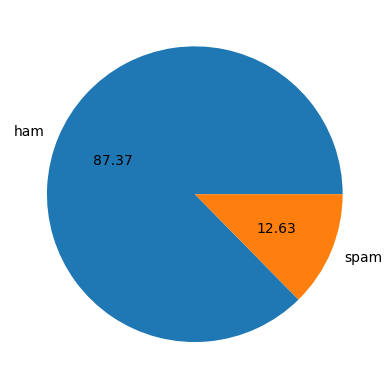

In [279]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [280]:
# our data is highly imbalanced

In [281]:
import nltk

In [282]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [283]:
#fro analysus of text columns we will create new columns

In [284]:
df['num_chars']=df['text'].apply(len)

In [285]:
df.head()

,target,text,num_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [286]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [287]:
df.head()

,target,text,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [288]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [289]:
df.head()

,target,text,num_chars,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [290]:
#now checking all new created columns
df[['num_chars','num_words','num_sent']].describe()

,num_chars,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [291]:
#see max in each in columns is a outlier
#for better we will analyse ham and spam seprately

In [292]:
df[df['target']==0][['num_chars','num_words','num_sent']].describe()


,num_chars,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [293]:
df[df['target']==1][['num_chars','num_words','num_sent']].describe()

,num_chars,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [294]:
#we ca see spam messages are longer 
# we will draw graph for better understanding

In [295]:
import seaborn as sns

<Axes: xlabel='num_chars', ylabel='Count'>

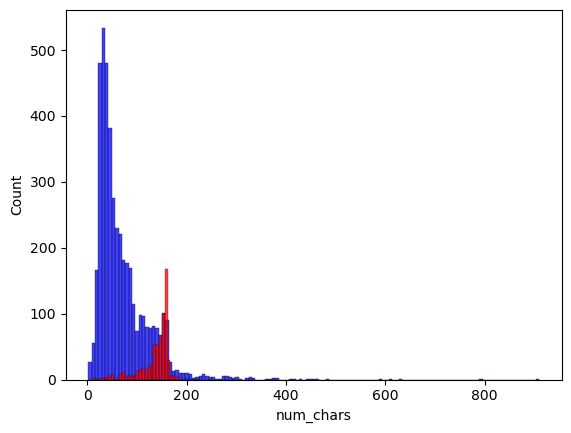

In [296]:
sns.histplot(df[df['target']==0]['num_chars'],color='blue')
sns.histplot(df[df['target']==1]['num_chars'],color='red')

In [297]:
# most ham messages are of less char and there is some outlier in ham

<Axes: xlabel='num_words', ylabel='Count'>

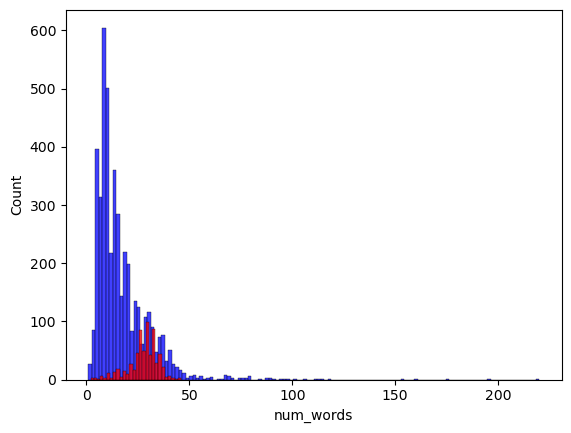

In [298]:
sns.histplot(df[df['target']==0]['num_words'],color='blue')
sns.histplot(df[df['target']==1]['num_words'],color='red')

In [299]:
#same observations

In [300]:
#seeing relation betweens columns

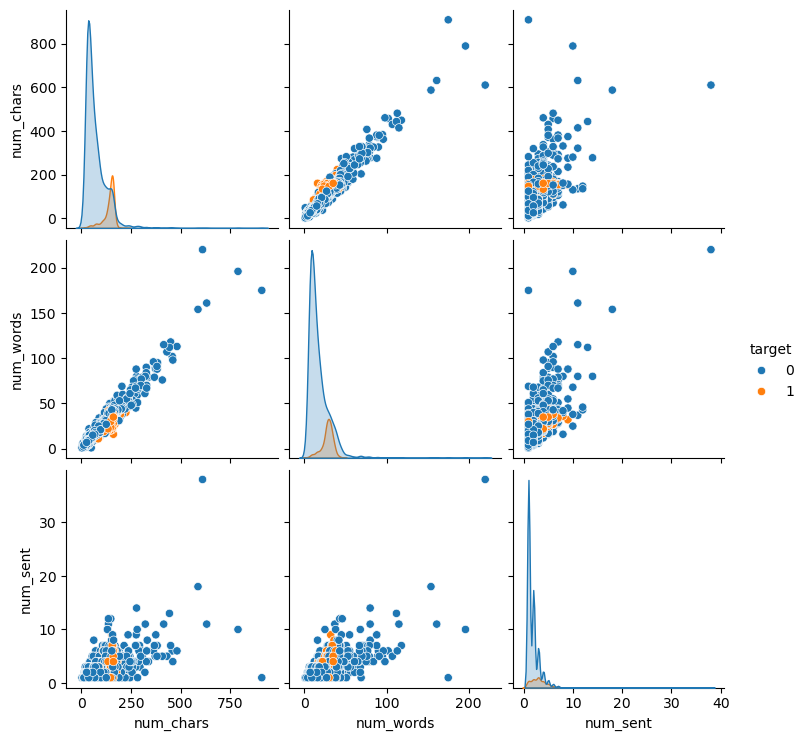

In [301]:
sns.pairplot(df,hue='target')

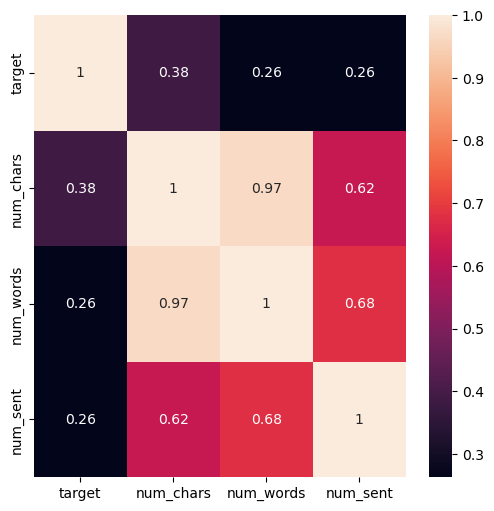

In [302]:
plt.figure(figsize=(6,6))
sns.heatmap(df[['target','num_chars','num_words','num_sent']].corr(), annot=True)
plt.show()

In [303]:
#there is multicollinearity so for model  so we will be taking only one features outoff these three let's char

# Data Preprocessing
1.Lowercase
2.Tokenisation
3.Removing StopWords and Punctuation
4.Stemming

In [304]:
# stopwords and punctuation
from nltk.corpus import stopwords
import string
print(string.punctuation)
print(stopwords.words('english'))

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's

In [305]:
#stemming
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('doing')

'do'

In [306]:
#lowercase and tokenize
# we will remove special character i.e keeping only those char which are alpha numeric
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [307]:
transform_text("AYuSh Is Very GOOD % $$ &&& Boy as he is reading books")

'ayush good boy read book'

In [308]:
# transforming text columns
df['transformed_text']=df['text'].apply(transform_text)

In [309]:
df.head()

,target,text,num_chars,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [310]:
# we will make word cloud ( word cloud shows important words in bigger size and less important words in smaller size based on how often they appear.)

In [311]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [312]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

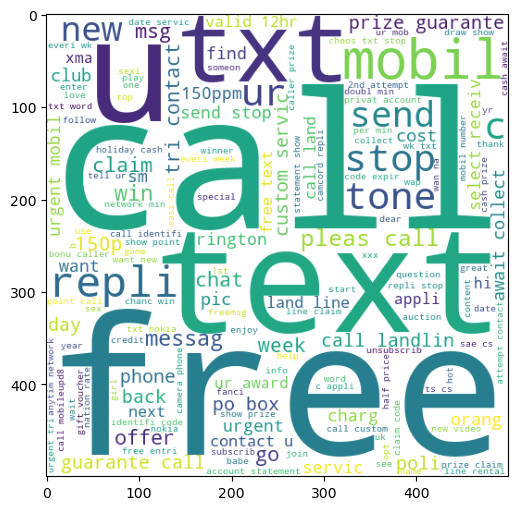

In [313]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [314]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

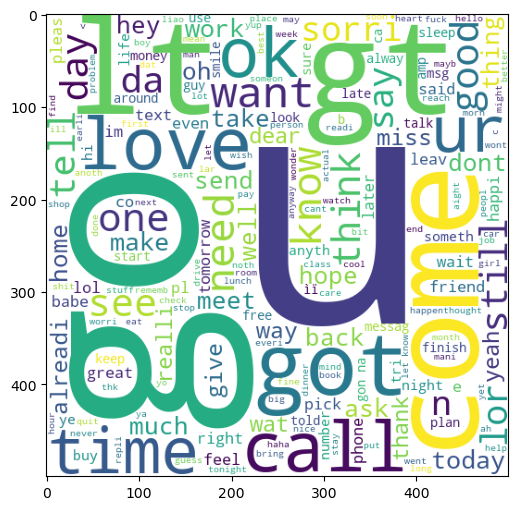

In [315]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [316]:
# let's see top 50 words of spam and non-spam

In [317]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)



In [318]:
len(spam_corpus)

9939

In [319]:
from collections import Counter

spam_df = pd.DataFrame(Counter(spam_corpus).most_common(50),
                       columns=['word', 'count'])
spam_df.head()

,word,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122


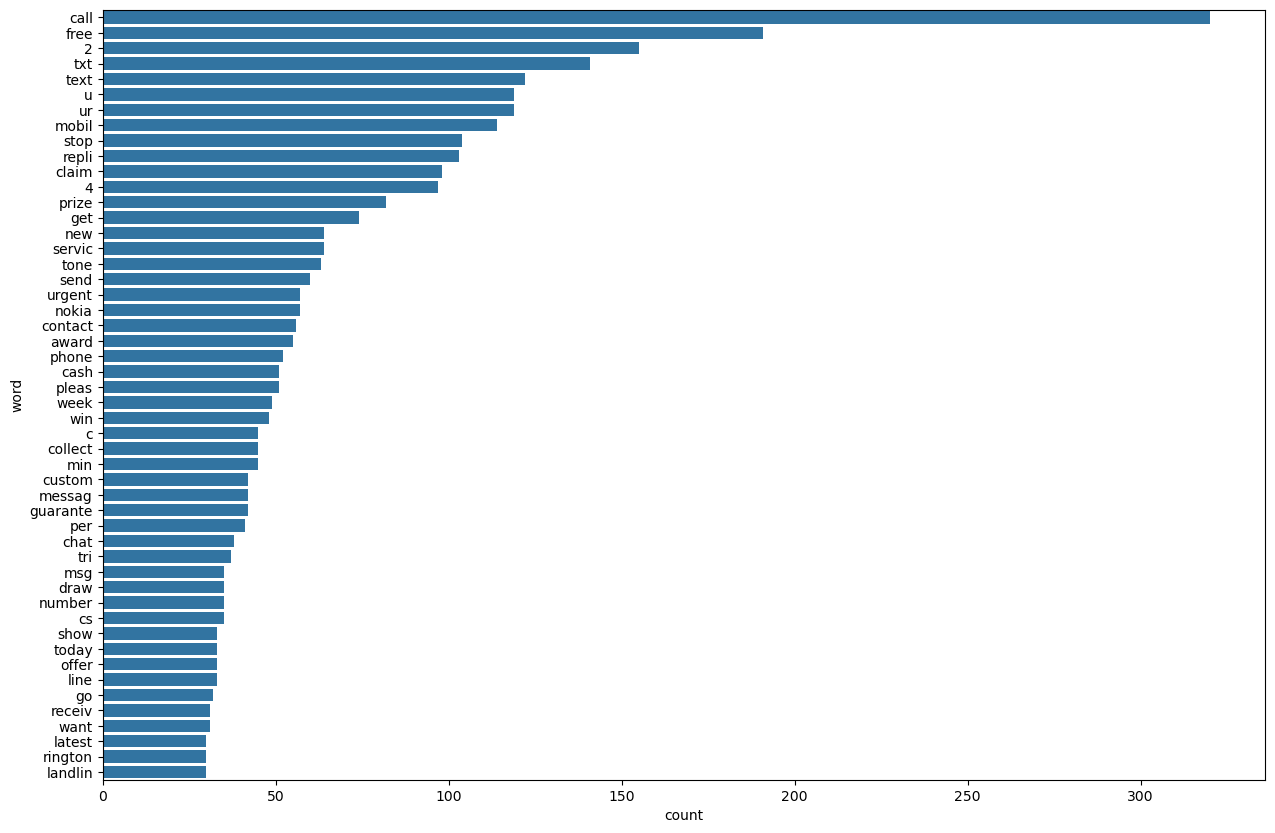

In [320]:
plt.figure(figsize=(15,10))
sns.barplot(x='count', y='word', data=spam_df)
plt.show()

In [321]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)


In [322]:
len(ham_corpus)

35404

In [323]:
from collections import Counter

ham_df = pd.DataFrame(Counter(ham_corpus).most_common(50),
                       columns=['word', 'count'])
ham_df.head()

,word,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287


In [324]:
# NB is cosidered to be good on textual data and we will chech for other also

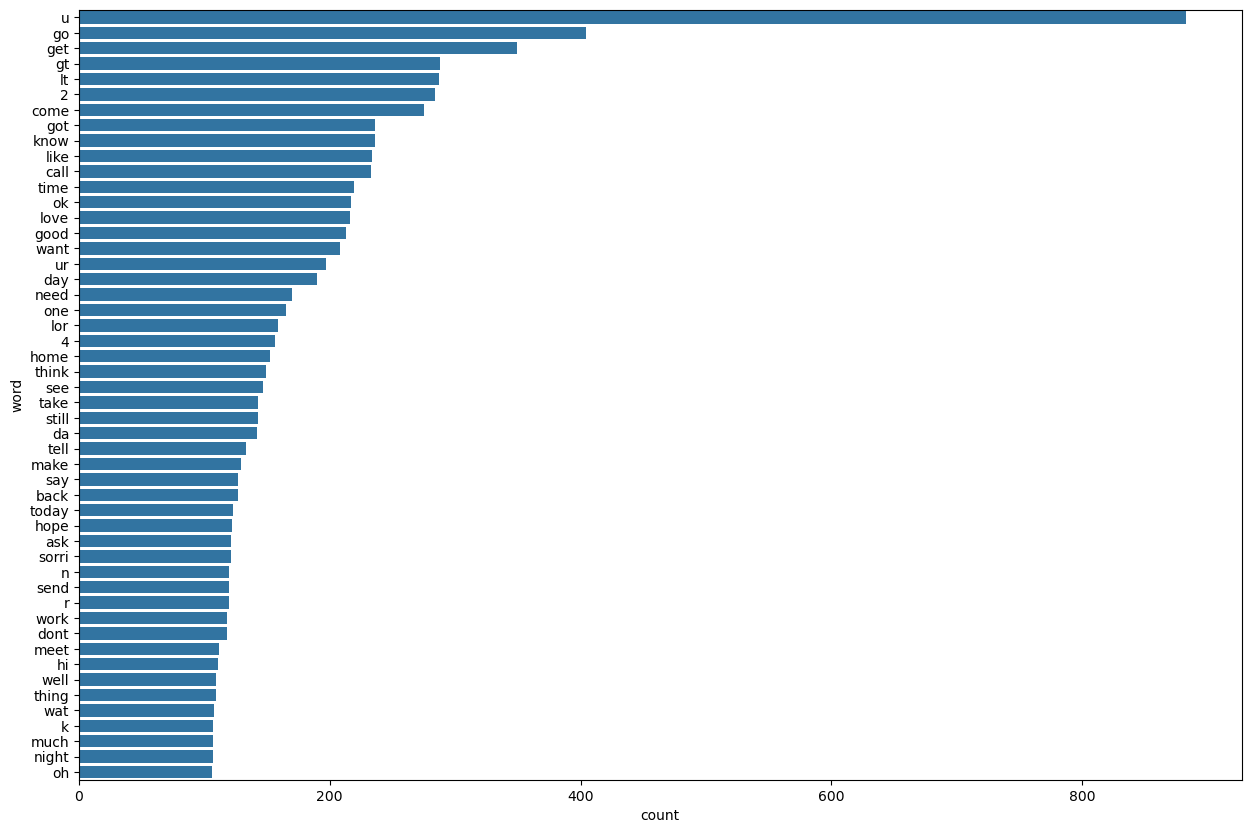

In [325]:
plt.figure(figsize=(15,10))
sns.barplot(x='count', y='word', data=ham_df)
plt.show()

# Model Building

In [326]:
# NB is considered to be good on textual data and we will check other also
# first we will vectorize word using Tfidf/Bag of word before that x,y train test split


In [327]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [328]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [329]:
x.shape

(5169, 6708)

In [330]:
y=df['target'].values

In [331]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [332]:
from sklearn.model_selection import train_test_split

In [333]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [334]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [335]:
# as we don't know distribution so we are importing all NB
## As our data is imbalanced so metrics is more important than accuracy score precision very matter over accuracy

In [336]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [337]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [338]:
# precision is very poor

In [339]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [340]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [341]:
# as precision matter so we will use mnb

In [342]:
# we can also train using other algorithm  like Xgboost,RF,KNN

In [343]:
# Model Improvement
# let's try to improve accuracy as precision is okay
# 1.let's use max_feature like instead of using all words from corpus use top 3000 words mnb 95--97
# we apply scaling but it didn't improve anything so don't use (although we use min max scler instead of standrad scaler as it give -ve value and NB don't acceot it)



# What we need to do with new input during prediction
1. Transform Text
2. Vectorizering
3. Model/Algorithm applying

In [344]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))